# Centroid Detection and Polynomial Regression System

This notebook provides core functions for centroid detection in segmentation maps and
polynomial regression for gaze point mapping.

## Table of Contents

1. [Imports](#imports)
2. [Segmentation Model](#segmentation-model)
3. [Image Region Extraction](#region-extraction)
4. [Centroid Detection](#centroid-detection)
5. [Visualization](#visualization)
6. [Batch Processing](#batch-processing)
7. [Gaze Data Processor](#data-processor)
8. [Polynomial Regression Model](#polynomial-model)
9. [Model Evaluation & Validation](#evaluation)
10. [Usage Example](#usage)

## <a name="imports"></a>Imports

In [45]:
import numpy as np
import os
from PIL import Image
import torch
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt
import json
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Imports loaded successfully!")

Imports loaded successfully!


## <a name="segmentation-model"></a>Segmentation Model (Optional)

In [46]:
import torch.nn as nn
import torch.nn.functional as F

# Depthwise Separable Convolution Blocks

class DepthwiseSeparableConv(nn.Module):
    """MobileNet V1 style depthwise separable convolution block"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=kernel_size, stride=stride, padding=padding,
            groups=in_channels, bias=False
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, stride=1, padding=0, bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.depthwise(x)))
        x = F.leaky_relu(self.bn2(self.pointwise(x)))
        return x


class DoubleConv2dBN(nn.Module):
    """Double depthwise separable convolution block"""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels, out_channels, kernel_size, stride, padding)
        self.conv2 = DepthwiseSeparableConv(out_channels, out_channels, kernel_size, stride, padding)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class Deconv2dBN(nn.Module):
    """Transposed convolution block"""
    def __init__(self, in_channels, out_channels, kernel_size=2, stride=2):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, bias=True)
        self.bn1 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        return F.leaky_relu(self.bn1(self.conv1(x)))


class NewUnet(nn.Module):
    """Lightweight U-Net architecture using depthwise separable convolutions.
    This is the model used to train best_model.pth."""
    def __init__(self):
        super(NewUnet, self).__init__()
        self.layer1_conv = DoubleConv2dBN(1, 12)
        self.pointwise = nn.Conv2d(2, 12, kernel_size=1, stride=1, padding=0, bias=False)
        self.layer2_conv = DoubleConv2dBN(12, 24)
        self.layer3_conv = DoubleConv2dBN(24, 12)
        self.layer4_conv = nn.Conv2d(12, 3, kernel_size=3, stride=1, padding=1, bias=True)
        self.deconv1 = Deconv2dBN(24, 12)
        self.bn1 = nn.BatchNorm2d(12)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Note: Use pointwise for experimental data validation
        conv1_2 = self.pointwise(x)
        pool1 = F.max_pool2d(conv1_2, 2)
        
        conv2 = self.layer2_conv(pool1)
        convt1 = self.deconv1(conv2)
        concat1 = torch.cat([convt1, conv1_2], dim=1)
        conv3 = self.layer3_conv(concat1)
        
        conv4 = self.layer4_conv(conv3)
        outp = self.sigmoid(conv4)
        return outp



# Test model
model = NewUnet()
test_input = torch.rand(1, 2, 300, 300)
test_output = model(test_input)
print(f"MetaUnet2 model loaded! Output shape: {test_output.shape}")

MetaUnet2 model loaded! Output shape: torch.Size([1, 3, 300, 300])


## <a name="region-extraction"></a>Image Region Extraction

In [47]:
def extract_four_regions(image_path, output_path=None, regions=None):
    """
    Extract four regions from a PNG image and return as a (2, 300, 300) array.
    
    Args:
        image_path: Path to PNG image file
        output_path: Output file path (optional, saves as .npy if provided)
        regions: List of four region coordinates [(x1, y1, x2, y2), ...]
                 If None, uses default four corner regions
    
    Returns:
        result_array: (2, 300, 300) array containing difference images
    """
    # Open image
    try:
        img = Image.open(image_path)
    except Exception as e:
        print(f"Cannot open image: {e}")
        return None
    
    # Convert to NumPy array
    img_array = np.array(img)
    
    # Use default corner regions if none provided
    if regions is None:
        regions = [
            (132, 3633, 1632, 5120),  # Top-right
            (3630, 3558, 5120, 5058),  # Bottom-right  
            (36, 101, 1536, 1601),     # Top-left
            (3577, 30, 5077, 1530)     # Bottom-left
        ]
    
    # Ensure exactly four regions
    if len(regions) != 4:
        print("Need exactly four region coordinates")
        return None
    
    # Extract four regions
    extracted_regions = []
    for i, (x1, y1, x2, y2) in enumerate(regions):
        # Extract region
        region = img_array[x1:x2, y1:y2]
        
        h, w = region.shape[:2]
        # Pad to square if needed
        if h != w:
            max_dim = max(h, w)
            pad_h = max_dim - h
            pad_w = max_dim - w
            
            if region.ndim == 3:
                region = np.pad(region, ((0, pad_h), (0, pad_w), (0, 0)), 
                               mode='constant', constant_values=0)
            else:
                region = np.pad(region, ((0, pad_h), (0, pad_w)), 
                               mode='constant', constant_values=0)
        
        # Resize to 300x300 if needed
        if region.shape[0] != 300 or region.shape[1] != 300:
            region_img = Image.fromarray(region)
            region_img = region_img.resize((300, 300))
            region = np.array(region_img)
        
        extracted_regions.append(region)
    
    # Convert to (4, 300, 300, 3) array
    if len(extracted_regions) == 4:
        array = np.stack(extracted_regions, axis=0).astype(np.int16)
        
        # Compute differences
        diff1 = array[0] - array[2]   # Top-right - Top-left
        diff2 = array[1] - 0.2 * array[3]  # Bottom-right - 0.2*Bottom-left
        
        # Stack results into (2, 300, 300) array
        result_array = np.stack([diff1, diff2], axis=0)
        
        # Save if output path provided
        if output_path:
            np.save(output_path, result_array)
            print(f"Saved to: {output_path}")
        
        return result_array
    else:
        print("Cannot extract four valid regions")
        return None

# Test the function
print("extract_four_regions function loaded!")

def load_data_from_folder(data_folder):
    """
    Load image paths from a folder containing PNG files.
    
    Args:
        data_folder: Path to folder containing PNG images
    
    Returns:
        image_paths: List of image file paths
        label_paths: List of corresponding label file paths (if exist)
    """
    image_paths = []
    label_paths = []
    
    if not os.path.exists(data_folder):
        raise ValueError(f"Data folder does not exist: {data_folder}")
    
    png_files = [f for f in os.listdir(data_folder) if f.lower().endswith('.png')]
    
    print(f"Found {len(png_files)} PNG files")
    
    for png_file in sorted(png_files):
        img_path = os.path.join(data_folder, png_file)
        image_paths.append(img_path)
        
        base_name = os.path.splitext(png_file)[0]
        npy_file = base_name + '.npy'
        label_path = os.path.join(data_folder, npy_file)
        
        if os.path.exists(label_path):
            label_paths.append(label_path)
        else:
            print(f"Warning: Cannot find label file {label_path}")
            label_paths.append(None)
    
    valid_indices = [i for i, label_path in enumerate(label_paths) if label_path is not None]
    image_paths = [image_paths[i] for i in valid_indices]
    label_paths = [label_paths[i] for i in valid_indices]
    
    print(f"Valid data pairs: {len(image_paths)}")
    
    return image_paths, label_paths

extract_four_regions function loaded!


## <a name="centroid-detection"></a>Centroid Detection

In [48]:
def get_segmentation_results(predictions):
    """
    Convert model output to segmentation map using argmax.
    
    Args:
        predictions: Model output tensor (batch_size, num_classes, height, width)
    
    Returns:
        segmentation_results: Segmentation map tensor (batch_size, height, width)
    """
    segmentation_results = torch.argmax(predictions, dim=1)
    return segmentation_results


def find_class_centroids(segmentation_map, target_class=2, min_area=10, only_largest=True):
    """
    Find connected regions of a specific class and calculate centroids.
    
    Args:
        segmentation_map: Segmentation result map (H, W)
        target_class: Target class value (default: 2)
        min_area: Minimum region area in pixels (default: 10)
        only_largest: If True, return only largest region centroid
    
    Returns:
        centroids: List of centroid coordinates [(x1, y1), ...]
        regions_info: List of region information dictionaries
    """
    # Create binary mask for target class
    binary_mask = (segmentation_map == target_class).astype(np.uint8)
    
    if np.sum(binary_mask) == 0:
        return [], []
    
    # Use connected component analysis
    labeled_array, num_features = ndimage.label(binary_mask)
    
    regions_info = []
    
    for label in range(1, num_features + 1):
        region_mask = (labeled_array == label).astype(np.uint8)
        area = np.sum(region_mask)
        
        # Filter small regions
        if area < min_area:
            continue
        
        # Calculate centroid using moments
        M = cv2.moments(region_mask)
        
        if M['m00'] != 0:
            cx = M['m10'] / M['m00']
            cy = M['m01'] / M['m00']
            
            regions_info.append({
                'label': label,
                'area': area,
                'centroid': (cx, cy),
                'region_mask': region_mask.copy()
            })
    
    if not regions_info:
        return [], []
    
    # Return only largest or all centroids
    if only_largest:
        largest_region = max(regions_info, key=lambda x: x['area'])
        return [largest_region['centroid']], regions_info
    else:
        centroids = [info['centroid'] for info in regions_info]
        return centroids, regions_info

# Test the functions
print("Centroid detection functions loaded!")

Centroid detection functions loaded!


## <a name="visualization"></a>Visualization

In [49]:
def colorize_segmentation(segmentation_map):
    """
    Convert segmentation map to color image.
    
    Args:
        segmentation_map: Segmentation map with class values
    
    Returns:
        Colored segmentation image
    """
    color_map = {
        0: [0, 0, 0],      # Background - Black
        1: [128, 0, 128],  # Class 1 - Purple
        2: [0, 255, 0],    # Class 2 - Green
        3: [255, 165, 0]   # Class 3 - Orange
    }
    
    h, w = segmentation_map.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_val, color in color_map.items():
        mask = segmentation_map == class_val
        colored[mask] = color
    
    return colored


def visualize_with_centroids(original_img_path, segmentation_map, centroids, regions_info=None,
                             save_path=None, figsize=(15, 5), target_class=2):
    """
    Visualize original image, segmentation result, and centroid positions.
    
    Args:
        original_img_path: Path to original image
        segmentation_map: Segmentation result map
        centroids: List of centroid coordinates
        regions_info: List of region information (optional)
        save_path: Path to save visualization
        figsize: Figure size
        target_class: Target class value
    """
    # Read original image
    original_img = np.array(Image.open(original_img_path))
    
    # Create colored segmentation map
    colored_seg = colorize_segmentation(segmentation_map)
    
    # Create image with centroid markers
    marked_img = colored_seg.copy()
    if len(marked_img.shape) == 2:
        marked_img = np.stack([marked_img] * 3, axis=-1)
    elif marked_img.shape[2] == 4:
        marked_img = marked_img[:, :, :3]
    
    # Draw centroids
    for i, (cx, cy) in enumerate(centroids):
        cx_int, cy_int = int(round(cx)), int(round(cy))
        
        if i == 0 and len(centroids) == 1 and regions_info and len(regions_info) > 1:
            # Largest region - Red marker
            cv2.circle(marked_img, (cx_int, cy_int), 10, (0, 0, 255), -1)
            cv2.circle(marked_img, (cx_int, cy_int), 12, (255, 255, 0), 2)
        else:
            # Other regions - Yellow marker
            cv2.circle(marked_img, (cx_int, cy_int), 6, (0, 255, 255), -1)
            cv2.circle(marked_img, (cx_int, cy_int), 8, (255, 0, 0), 2)
    
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(colored_seg)
    axes[1].set_title(f'Segmentation (Class {target_class})')
    axes[1].axis('off')
    
    axes[2].imshow(marked_img)
    axes[2].set_title(f'Centroids ({len(centroids)})')
    axes[2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    plt.close()

# Test visualization functions
print("Visualization functions loaded!")

Visualization functions loaded!


## <a name="batch-processing"></a>Batch Processing

In [50]:
def save_all_segmentations(model, test_image_paths, regions=None, output_dir='./segmentation_results_data',
                           device='cpu', only_largest_class2=True):
    """
    Batch process images to save segmentation results and find centroids.
    
    Args:
        model: Trained segmentation model
        test_image_paths: List of test image paths
        regions: Image regions to extract (optional)
        output_dir: Output directory
        device: Computing device
        only_largest_class2: Whether to return only largest class 2 region
    
    Returns:
        df_centroids: DataFrame containing centroid information
    """
    model.eval()
    model.to(device)
    
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    npy_dir = os.path.join(output_dir, 'npy_files')
    vis_dir = os.path.join(output_dir, 'visualizations')
    os.makedirs(npy_dir, exist_ok=True)
    os.makedirs(vis_dir, exist_ok=True)
    
    centroids_records = []
    
    for idx, img_path in enumerate(test_image_paths):
        try:
            # Extract features and predict
            input_array = extract_four_regions(img_path, regions=regions)
            if input_array is None:
                continue
                
            input_tensor = torch.from_numpy(input_array).float().unsqueeze(0).to(device)
            
            with torch.no_grad():
                output = model(input_tensor)
                predictions = get_segmentation_results(output)
                predictions_np = predictions.squeeze().cpu().numpy()
            
            # Save as .npy file
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            npy_path = os.path.join(npy_dir, f'{base_name}_seg.npy')
            np.save(npy_path, predictions_np)
            
            # Calculate centroids for class 2 regions
            centroids, regions_info = find_class_centroids(
                predictions_np, 
                target_class=2, 
                min_area=10, 
                only_largest=only_largest_class2
            )
            
            # Record centroid information
            for centroid in centroids:
                centroids_records.append({
                    'image_name': os.path.basename(img_path),
                    'class': 2,
                    'centroid_x': float(centroid[0]),
                    'centroid_y': float(centroid[1]),
                    'is_largest': True
                })
            
            # Visualize results
            vis_path = os.path.join(vis_dir, f'{base_name}_centroids.png')
            visualize_with_centroids(
                img_path, predictions_np, centroids, regions_info,
                save_path=vis_path, target_class=2
            )
            
            if (idx + 1) % 10 == 0:
                print(f"Processed {idx + 1}/{len(test_image_paths)} images...")
                
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    # Save centroid results to CSV
    if centroids_records:
        df_centroids = pd.DataFrame(centroids_records)
        csv_path = os.path.join(output_dir, 'class2_centroids.csv')
        df_centroids.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"\nCentroid results saved to: {csv_path}")
        print(f"Total centroids found: {len(df_centroids)}")
    else:
        df_centroids = None
    
    # Save summary statistics
    stats = {
        'total_images': len(test_image_paths),
        'processed_images': idx + 1,
        'total_centroids_found': len(centroids_records),
        'output_directory': output_dir
    }
    
    stats_path = os.path.join(output_dir, 'processing_stats.json')
    with open(stats_path, 'w', encoding='utf-8') as f:
        json.dump(stats, f, indent=2, ensure_ascii=False)
    
    print(f"\nAll results saved to: {output_dir}")
    
    return df_centroids

# Test batch processing function
print("Batch processing function loaded!")


Batch processing function loaded!


In [51]:
class GazeDataProcessor:
    """Gaze data processing and matching class"""
    
    def __init__(self, angle_csv_path=None, coord_csv_path=None):
        """
        Initialize processor.
        
        Args:
            angle_csv_path: Path to angle data CSV file
            coord_csv_path: Path to coordinate data CSV file
        """
        self.angle_csv_path = angle_csv_path
        self.coord_csv_path = coord_csv_path
        self.df_angles = None
        self.df_coords = None
        self.df_merged = None
        self.eye_points = None
        self.screen_points = None
        self.filenames = None
        
    def load_angle_data(self, csv_path=None, sep=',', path_col='image_path', 
                       angle_x_col='angle_x', angle_y_col='angle_y'):
        """
        Load angle data from CSV.
        
        Args:
            csv_path: CSV file path
            sep: Delimiter, default is comma
            path_col: Image path column name
            angle_x_col: X angle column name
            angle_y_col: Y angle column name
        """
        if csv_path is None:
            csv_path = self.angle_csv_path
            
        print(f"Loading angle data: {csv_path}")
        
        try:
            self.df_angles = pd.read_csv(csv_path, sep=sep)
            print(f"Angle data columns: {list(self.df_angles.columns)}")
            
            if path_col in self.df_angles.columns:
                self.df_angles = self.df_angles.rename(columns={
                    path_col: 'image_path',
                    angle_x_col: 'angle_x',
                    angle_y_col: 'angle_y'
                })
            
            self.df_angles['filename'] = self.df_angles['image_path'].apply(os.path.basename)
            
            print(f"Successfully loaded {len(self.df_angles)} angle data records")
            print(f"Data preview:")
            print(self.df_angles.head())
            
            return self.df_angles
            
        except Exception as e:
            print(f"Failed to load angle data: {e}")
            return None
    
    def load_coordinate_data(self, csv_path=None, sep=',', filename_col='image_name',
                           coord_x_col='centroid_x', coord_y_col='centroid_y'):
        """
        Load coordinate data from CSV.
        
        Args:
            csv_path: CSV file path
            sep: Delimiter, default is comma
            filename_col: Filename column name
            coord_x_col: X coordinate column name
            coord_y_col: Y coordinate column name
        """
        if csv_path is None:
            csv_path = self.coord_csv_path
            
        print(f"Loading coordinate data: {csv_path}")
        
        try:
            self.df_coords = pd.read_csv(csv_path, sep=sep)
            print(f"Coordinate data columns: {list(self.df_coords.columns)}")
            
            if filename_col in self.df_coords.columns:
                self.df_coords = self.df_coords.rename(columns={
                    filename_col: 'filename',
                    coord_x_col: 'coord_x',
                    coord_y_col: 'coord_y'
                })
            
            print(f"Successfully loaded {len(self.df_coords)} coordinate data records")
            print(f"Data preview:")
            print(self.df_coords.head())
            
            return self.df_coords
            
        except Exception as e:
            print(f"Failed to load coordinate data: {e}")
            return None
    
    def match_data(self, how='inner'):
        """
        Match angle and coordinate data by filename.
        
        Args:
            how: Merge method (inner, left, right, outer)
        
        Returns:
            df_merged: Merged DataFrame
        """
        if self.df_angles is None or self.df_coords is None:
            print("Please load angle and coordinate data first")
            return None
        
        self.df_merged = pd.merge(self.df_angles, self.df_coords, on='filename', how=how)
        print(f"Matched data: {len(self.df_merged)} records")
        
        self.eye_points = self.df_merged[['angle_x', 'angle_y']].values
        self.screen_points = self.df_merged[['coord_x', 'coord_y']].values
        self.filenames = self.df_merged['filename'].values
        
        return self.df_merged
    
    def split_data(self, test_size=0.2, random_state=42):
        """
        Split data into training and testing sets.
        
        Args:
            test_size: Proportion of test data
            random_state: Random seed
        
        Returns:
            eye_train, eye_test, screen_train, screen_test
        """
        if self.eye_points is None or self.screen_points is None:
            print("Please match data first")
            return None, None, None, None
        
        return train_test_split(
            self.eye_points, self.screen_points,
            test_size=test_size, random_state=random_state
        )
    
    def save_matched_data(self, output_path='matched_gaze_data.csv'):
        """
        Save matched data to CSV.
        
        Args:
            output_path: Output CSV file path
        
        Returns:
            output_path: Path to saved file
        """
        if self.df_merged is None:
            print("No matched data to save")
            return None
        
        os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
        self.df_merged.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"Matched data saved to: {output_path}")
        
        return output_path

print("GazeDataProcessor class loaded!")


GazeDataProcessor class loaded!


## <a name="polynomial-model"></a>Polynomial Regression Model

In [52]:
class GazePolynomialModel:
    """
    Polynomial regression model for gaze point mapping.
    Maps eye tracking points to screen coordinates using polynomial features.
    """
    
    def __init__(self, degree=2, alpha=0.0):
        """
        Initialize polynomial regression model.
        
        Args:
            degree: Polynomial degree (default: 2)
            alpha: Regularization parameter (default: 0 for linear regression)
                  Use alpha > 0 for Ridge regression
        """
        self.degree = degree
        self.alpha = alpha
        self.poly = PolynomialFeatures(degree=degree, include_bias=True)
        self.scaler = StandardScaler()
        
        # Initialize models
        self.model_x = LinearRegression()
        self.model_y = LinearRegression()
        
        # Model parameters
        self.coefficients_x = None
        self.coefficients_y = None
        self.intercept_x = None
        self.intercept_y = None
        self.poly_feature_names = None
        self.scaler_mean = None
        self.scaler_scale = None
        self.is_fitted = False
        
    def fit(self, eye_points, screen_points):
        """
        Train the model.
        
        Args:
            eye_points: Input eye tracking points (n_samples, 2)
            screen_points: Target screen coordinates (n_samples, 2)
        """
        print(f"Training polynomial regression model (degree={self.degree}, alpha={self.alpha})...")
        
        # Generate polynomial features
        X_poly = self.poly.fit_transform(eye_points)
        self.poly_feature_names = self.poly.get_feature_names_out(['eye_x', 'eye_y'])
        
        # Standardize features
        X_scaled = self.scaler.fit_transform(X_poly)
        self.scaler_mean = self.scaler.mean_
        self.scaler_scale = self.scaler.scale_

        # Train X direction model
        self.model_x.fit(X_scaled, screen_points[:, 0])
        self.coefficients_x = self.model_x.coef_
        self.intercept_x = self.model_x.intercept_

        # Train Y direction model
        self.model_y.fit(X_scaled, screen_points[:, 1])
        self.coefficients_y = self.model_y.coef_
        self.intercept_y = self.model_y.intercept_
        
        self.is_fitted = True
        print("Model training completed.")
        self._print_coefficients()
        return self
    
    def _print_coefficients(self):
        """
        Print model coefficients.
        """
        print("\n" + "="*60)
        print("Model Coefficients Information:")
        print("="*60)
        
        print(f"\nPolynomial features (degree={self.degree}):")
        for i, name in enumerate(self.poly_feature_names):
            print(f"  {i}: {name}")
        
        print(f"\nX direction model coefficients ({len(self.coefficients_x)} total):")
        for i, (name, coeff) in enumerate(zip(self.poly_feature_names, self.coefficients_x)):
            print(f"  {name}: {coeff:.6f}")
        print(f"  Intercept: {self.intercept_x:.6f}")
        
        print(f"\nY direction model coefficients ({len(self.coefficients_y)} total):")
        for i, (name, coeff) in enumerate(zip(self.poly_feature_names, self.coefficients_y)):
            print(f"  {name}: {coeff:.6f}")
        print(f"  Intercept: {self.intercept_y:.6f}")
        
        print(f"\nStandardScaler parameters:")
        print(f"  Mean: {self.scaler_mean}")
        print(f"  Scale: {self.scaler_scale}")
        print("="*60)
    
    def get_coefficients(self):
        """
        Get all model coefficients.
        
        Returns:
            Dictionary containing all model coefficients
        """
        if not self.is_fitted:
            raise ValueError("Model not trained yet. Please call fit() first.")
        
        return {
            'degree': self.degree,
            'alpha': self.alpha,
            'poly_feature_names': self.poly_feature_names,
            'coefficients_x': self.coefficients_x,
            'coefficients_y': self.coefficients_y,
            'intercept_x': self.intercept_x,
            'intercept_y': self.intercept_y,
            'scaler_mean': self.scaler_mean,
            'scaler_scale': self.scaler_scale
        }
    
    def save_coefficients(self, filepath='model_coefficients.pkl'):
        """
        Save model coefficients to file.
        
        Args:
            filepath: Output file path
        """
        import pickle
        
        if not self.is_fitted:
            raise ValueError("Model not trained. Cannot save coefficients.")
        
        model_data = {
            'degree': self.degree,
            'alpha': self.alpha,
            'poly_feature_names': self.poly_feature_names,
            'coefficients_x': self.coefficients_x,
            'coefficients_y': self.coefficients_y,
            'intercept_x': self.intercept_x,
            'intercept_y': self.intercept_y,
            'scaler_mean': self.scaler_mean,
            'scaler_scale': self.scaler_scale,
            'is_fitted': self.is_fitted
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"Model coefficients saved to: {filepath}")
        
        # Also save as text file for easy viewing
        txt_filepath = filepath.replace('.pkl', '.txt')
        self.save_coefficients_txt(txt_filepath)
        
        return filepath
    
    def save_coefficients_txt(self, filepath='model_coefficients.txt'):
        """
        Save model coefficients to text file.
        
        Args:
            filepath: Output file path
        """
        if not self.is_fitted:
            raise ValueError("Model not trained. Cannot save coefficients.")
        
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write("Gaze Point Mapping Model Coefficients\n")
            f.write("="*60 + "\n\n")
            
            f.write(f"Model Configuration:\n")
            f.write(f"  Polynomial Degree: {self.degree}\n")
            f.write(f"  Alpha (regularization): {self.alpha}\n")
            f.write(f"  Is Fitted: {self.is_fitted}\n\n")
            
            f.write("Polynomial Features:\n")
            for i, name in enumerate(self.poly_feature_names):
                f.write(f"  {i}: {name}\n")
            f.write("\n")
            
            f.write("StandardScaler Parameters:\n")
            f.write(f"  Mean: {self.scaler_mean}\n")
            f.write(f"  Scale: {self.scaler_scale}\n\n")
            
            f.write("X Direction Model Coefficients:\n")
            f.write(f"  Intercept: {self.intercept_x:.10f}\n")
            for i, (name, coeff) in enumerate(zip(self.poly_feature_names, self.coefficients_x)):
                f.write(f"  {name}: {coeff:.10f}\n")
            f.write("\n")
            
            f.write("Y Direction Model Coefficients:\n")
            f.write(f"  Intercept: {self.intercept_y:.10f}\n")
            for i, (name, coeff) in enumerate(zip(self.poly_feature_names, self.coefficients_y)):
                f.write(f"  {name}: {coeff:.10f}\n")
        
        print(f"Model coefficients (text) saved to: {filepath}")
        return filepath
    
    def predict(self, eye_points):
        """
        Predict screen coordinates from eye tracking points.
        
        Args:
            eye_points: Input eye tracking points (n_samples, 2) or (2,)
        
        Returns:
            Predicted screen coordinates (n_samples, 2) or (2,)
        """
        if not self.is_fitted:
            raise ValueError("Model not trained. Please call fit() first.")
        
        # Handle single sample
        single_sample = eye_points.ndim == 1
        if single_sample:
            eye_points = eye_points.reshape(1, -1)
        
        # Generate polynomial features
        X_poly = self.poly.transform(eye_points)
        
        # Standardize features
        X_scaled = self.scaler.transform(X_poly)
        
        # Predict
        pred_x = self.model_x.predict(X_scaled)
        pred_y = self.model_y.predict(X_scaled)
        
        result = np.column_stack([pred_x, pred_y])
        
        # Return single sample format if input was single
        if single_sample:
            return result[0]
        return result
    
    def evaluate(self, eye_points, screen_points, verbose=True):
        """
        Evaluate model performance.
        
        Args:
            eye_points: Input eye tracking points
            screen_points: Target screen coordinates
            verbose: Whether to print results
        
        Returns:
            Dictionary containing evaluation metrics
        """
        if not self.is_fitted:
            raise ValueError("Model not trained. Please call fit() first.")
        
        # Predict
        predictions = self.predict(eye_points)
        
        # Calculate metrics
        mse_x = mean_squared_error(screen_points[:, 0], predictions[:, 0])
        mse_y = mean_squared_error(screen_points[:, 1], predictions[:, 1])
        mse_total = mean_squared_error(screen_points.flatten(), predictions.flatten())
        
        mae_x = mean_absolute_error(screen_points[:, 0], predictions[:, 0])
        mae_y = mean_absolute_error(screen_points[:, 1], predictions[:, 1])
        mae_total = mean_absolute_error(screen_points.flatten(), predictions.flatten())
        
        rmse_x = np.sqrt(mse_x)
        rmse_y = np.sqrt(mse_y)
        rmse_total = np.sqrt(mse_total)
        
        # Calculate correlation coefficients
        corr_x, p_x = pearsonr(screen_points[:, 0], predictions[:, 0])
        corr_y, p_y = pearsonr(screen_points[:, 1], predictions[:, 1])
        
        if verbose:
            print("\nModel Performance Evaluation:")
            print("=" * 60)
            print(f"{'Metric':<15} {'X Direction':<15} {'Y Direction':<15} {'Total':<15}")
            print("-" * 60)
            print(f"{'MSE':<15} {mse_x:<15.6f} {mse_y:<15.6f} {mse_total:<15.6f}")
            print(f"{'RMSE':<15} {rmse_x:<15.6f} {rmse_y:<15.6f} {rmse_total:<15.6f}")
            print(f"{'MAE':<15} {mae_x:<15.6f} {mae_y:<15.6f} {mae_total:<15.6f}")
            print(f"{'Correlation':<15} {corr_x:<15.6f} {corr_y:<15.6f} {'-':<15}")
            print(f"{'P-value':<15} {p_x:<15.6f} {p_y:<15.6f} {'-':<15}")
        
        return {
            'mse_x': mse_x, 'mse_y': mse_y, 'mse_total': mse_total,
            'rmse_x': rmse_x, 'rmse_y': rmse_y, 'rmse_total': rmse_total,
            'mae_x': mae_x, 'mae_y': mae_y, 'mae_total': mae_total,
            'corr_x': corr_x, 'corr_y': corr_y,
            'p_x': p_x, 'p_y': p_y
        }
    
    def cross_validate(self, eye_points, screen_points, cv=5, verbose=True):
        """
        Cross-validation for the model.
        
        Args:
            eye_points: Input eye tracking points
            screen_points: Target screen coordinates
            cv: Number of folds
            verbose: Whether to print results
        
        Returns:
            Dictionary containing CV scores
        """
        # Generate polynomial features
        X_poly = self.poly.fit_transform(eye_points)
        X_scaled = self.scaler.fit_transform(X_poly)
        
        # Cross-validate X direction
        cv_scores_x = cross_val_score(self.model_x, X_scaled, screen_points[:, 0], 
                                     cv=cv, scoring='neg_mean_squared_error')
        mse_scores_x = -cv_scores_x
        rmse_scores_x = np.sqrt(mse_scores_x)
        
        # Cross-validate Y direction
        cv_scores_y = cross_val_score(self.model_y, X_scaled, screen_points[:, 1], 
                                     cv=cv, scoring='neg_mean_squared_error')
        mse_scores_y = -cv_scores_y
        rmse_scores_y = np.sqrt(mse_scores_y)
        
        if verbose:
            print(f"\n{self.degree}-degree Polynomial Model Cross-Validation Results (cv={cv}):")
            print("=" * 60)
            print(f"{'Direction':<10} {'MSE Mean':<15} {'MSE Std':<15} {'RMSE Mean':<15} {'RMSE Std':<15}")
            print("-" * 60)
            print(f"{'X Direction':<10} {np.mean(mse_scores_x):<15.6f} {np.std(mse_scores_x):<15.6f} "
                  f"{np.mean(rmse_scores_x):<15.6f} {np.std(rmse_scores_x):<15.6f}")
            print(f"{'Y Direction':<10} {np.mean(mse_scores_y):<15.6f} {np.std(mse_scores_y):<15.6f} "
                  f"{np.mean(rmse_scores_y):<15.6f} {np.std(rmse_scores_y):<15.6f}")
        
        return {
            'mse_x_scores': mse_scores_x, 'mse_y_scores': mse_scores_y,
            'rmse_x_scores': rmse_scores_x, 'rmse_y_scores': rmse_scores_y
        }
    
    def visualize_predictions(self, eye_points, screen_points, sample_size=961):
        """
        Visualize prediction results.
        
        Args:
            eye_points: Input eye tracking points
            screen_points: Target screen coordinates
            sample_size: Number of samples to visualize
        """
        if not self.is_fitted:
            raise ValueError("Model not trained. Please call fit() first.")
        
        # Predict
        predictions = self.predict(eye_points)
        
        # Randomly select samples
        if len(eye_points) > sample_size:
            indices = np.random.choice(len(eye_points), sample_size, replace=False)
            eye_sample = eye_points[indices]
            screen_sample = screen_points[indices]
            pred_sample = predictions[indices]
        else:
            eye_sample = eye_points
            screen_sample = screen_points
            pred_sample = predictions
        
        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Predicted vs True scatter plot
        axes[0].scatter(screen_sample[:, 0], pred_sample[:, 0], alpha=0.6, label='X Direction')
        axes[0].scatter(screen_sample[:, 1], pred_sample[:, 1], alpha=0.6, label='Y Direction')
        
        # Add diagonal line (perfect prediction)
        min_val = min(screen_sample.min(), pred_sample.min())
        max_val = max(screen_sample.max(), pred_sample.max())
        axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Perfect Prediction')
        
        axes[0].set_xlabel('True Value')
        axes[0].set_ylabel('Predicted Value')
        axes[0].set_title(f'Predicted vs True (Polynomial Degree={self.degree})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_aspect('equal', adjustable='box')
        
        # Prediction error distribution
        errors_x = pred_sample[:, 0] - screen_sample[:, 0]
        errors_y = pred_sample[:, 1] - screen_sample[:, 1]
        
        axes[1].hist(errors_x, bins=20, alpha=0.7, label=f'X Direction (MAE={np.mean(np.abs(errors_x)):.4f})')
        axes[1].hist(errors_y, bins=20, alpha=0.7, label=f'Y Direction (MAE={np.mean(np.abs(errors_y)):.4f})')
        axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.7)
        axes[1].set_xlabel('Prediction Error')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title('Prediction Error Distribution')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

print("GazePolynomialModel class loaded!")

GazePolynomialModel class loaded!


## <a name="evaluation"></a>Model Evaluation & Validation

In [53]:
def validate_centroid_extraction(model, test_image_paths, device='cpu'):
    """
    Validate centroid extraction effectiveness.
    
    Args:
        model: Trained segmentation model
        test_image_paths: List of test image paths
        device: Computing device
    
    Returns:
        Dictionary containing validation results
    """
    print("="*60)
    print("Validating Centroid Extraction...")
    print("="*60)
    
    model.eval()
    model.to(device)
    
    results = {
        'total_images': len(test_image_paths),
        'successful_extractions': 0,
        'failed_extractions': 0,
        'total_centroids_found': 0,
        'class_distribution': {},
        'centroid_details': []
    }
    
    for img_path in test_image_paths:
        try:
            # Extract features
            input_array = extract_four_regions(img_path)
            if input_array is None:
                results['failed_extractions'] += 1
                continue
            
            input_tensor = torch.from_numpy(input_array).float().unsqueeze(0).to(device)
            
            with torch.no_grad():
                output = model(input_tensor)
                predictions = get_segmentation_results(output)
                predictions_np = predictions.squeeze().cpu().numpy()
            
            # Count classes
            unique, counts = np.unique(predictions_np, return_counts=True)
            for cls, cnt in zip(unique, counts):
                cls_key = int(cls)
                results['class_distribution'][cls_key] = results['class_distribution'].get(cls_key, 0) + cnt
            
            # Find centroids for class 2
            centroids, regions_info = find_class_centroids(predictions_np, target_class=2, min_area=10)
            
            if centroids:
                results['successful_extractions'] += 1
                results['total_centroids_found'] += len(centroids)
                results['centroid_details'].append({
                    'image': os.path.basename(img_path),
                    'centroids': centroids,
                    'num_regions': len(regions_info)
                })
            else:
                results['failed_extractions'] += 1
                
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            results['failed_extractions'] += 1
            continue
    
    # Print summary
    print(f"\nValidation Summary:")
    print(f"  Total images: {results['total_images']}")
    print(f"  Successful extractions: {results['successful_extractions']}")
    print(f"  Failed extractions: {results['failed_extractions']}")
    print(f"  Total centroids found: {results['total_centroids_found']}")
    print(f"  Success rate: {results['successful_extractions']/results['total_images']*100:.1f}%")
    
    print(f"\nClass Distribution:")
    for cls, cnt in sorted(results['class_distribution'].items()):
        print(f"  Class {cls}: {cnt} pixels")
    
    return results


def validate_polynomial_model(model, eye_points, screen_points, test_size=0.2, cv=5):
    """
    Validate polynomial regression model effectiveness.
    
    Args:
        model: GazePolynomialModel instance
        eye_points: Input eye tracking points
        screen_points: Target screen coordinates
        test_size: Fraction of data for testing
        cv: Number of cross-validation folds
    
    Returns:
        Dictionary containing validation results
    """
    print("="*60)
    print("Validating Polynomial Regression Model...")
    print("="*60)
    
    # Split data
    eye_train, eye_test, screen_train, screen_test = train_test_split(
        eye_points, screen_points, test_size=test_size, random_state=42
    )
    
    print(f"\nData Split:")
    print(f"  Training samples: {len(eye_train)}")
    print(f"  Testing samples: {len(eye_test)}")
    
    # Train model
    model.fit(eye_train, screen_train)
    
    # Cross-validation on training data
    print("\nCross-Validation Results:")
    cv_results = model.cross_validate(eye_train, screen_train, cv=cv, verbose=True)
    
    # Evaluate on test set
    print("\nTest Set Evaluation:")
    test_metrics = model.evaluate(eye_test, screen_test, verbose=True)
    
    # Visualize predictions
    print("\nGenerating prediction visualizations...")
    model.visualize_predictions(eye_test, screen_test)
    
    # Return comprehensive results
    return {
        'train_size': len(eye_train),
        'test_size': len(eye_test),
        'cv_results': cv_results,
        'test_metrics': test_metrics,
        'model_coefficients': model.get_coefficients()
    }


def comprehensive_validation(segmentation_model, gaze_model, test_image_paths, 
                             eye_points, screen_points, device='cpu'):
    """
    Comprehensive validation of both centroid extraction and polynomial regression.
    
    Args:
        segmentation_model: Trained segmentation model
        gaze_model: GazePolynomialModel instance
        test_image_paths: List of test image paths
        eye_points: Input eye tracking points
        screen_points: Target screen coordinates
        device: Computing device
    
    Returns:
        Dictionary containing all validation results
    """
    print("\n" + "#"*60)
    print("# COMPREHENSIVE VALIDATION")
    print("#"*60 + "\n")
    
    # Step 1: Validate centroid extraction
    print("STEP 1: Centroid Extraction Validation")
    centroid_results = validate_centroid_extraction(
        segmentation_model, test_image_paths, device
    )
    
    # Step 2: Validate polynomial regression
    print("\nSTEP 2: Polynomial Regression Validation")
    regression_results = validate_polynomial_model(
        gaze_model, eye_points, screen_points
    )
    
    # Step 3: Combined analysis
    print("\n" + "#"*60)
    print("# VALIDATION SUMMARY")
    print("#"*60)
    
    print(f"\n1. Centroid Extraction:")
    print(f"   - Success Rate: {centroid_results['successful_extractions']/centroid_results['total_images']*100:.1f}%")
    print(f"   - Total Centroids Found: {centroid_results['total_centroids_found']}")
    
    print(f"\n2. Polynomial Regression:")
    print(f"   - Test RMSE (Total): {regression_results['test_metrics']['rmse_total']:.4f}")
    print(f"   - Test MAE (Total): {regression_results['test_metrics']['mae_total']:.4f}")
    print(f"   - Correlation X: {regression_results['test_metrics']['corr_x']:.4f}")
    print(f"   - Correlation Y: {regression_results['test_metrics']['corr_y']:.4f}")
    
    # Overall assessment
    is_centroid_valid = centroid_results['successful_extractions'] / centroid_results['total_images'] > 0.5
    is_regression_valid = regression_results['test_metrics']['rmse_total'] < 100  # Adjust threshold as needed
    
    print(f"\n3. Overall Assessment:")
    print(f"   - Centroid Extraction: {'PASS' if is_centroid_valid else 'FAIL'}")
    print(f"   - Polynomial Regression: {'PASS' if is_regression_valid else 'FAIL'}")
    print(f"   - Overall Pipeline: {'PASS' if (is_centroid_valid and is_regression_valid) else 'FAIL'}")
    
    return {
        'centroid_results': centroid_results,
        'regression_results': regression_results,
        'overall_pass': is_centroid_valid and is_regression_valid
    }

print("Validation functions loaded!")

Validation functions loaded!


## <a name="usage"></a>Usage Example

Found 961 PNG files
Valid data pairs: 961


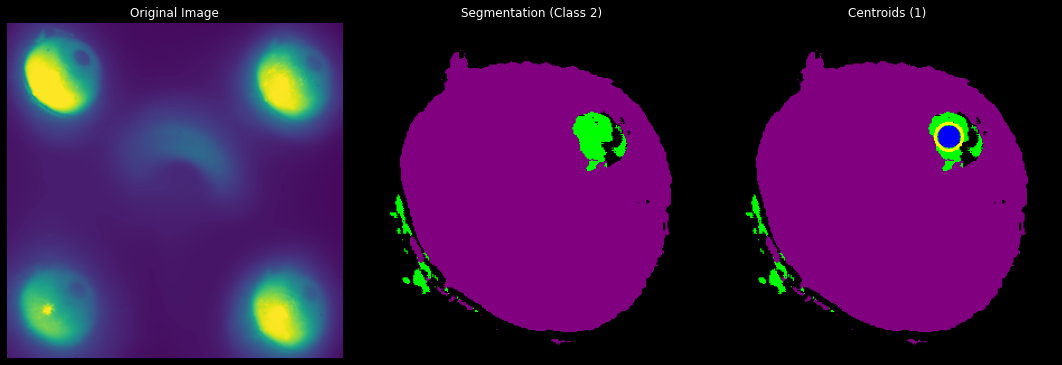

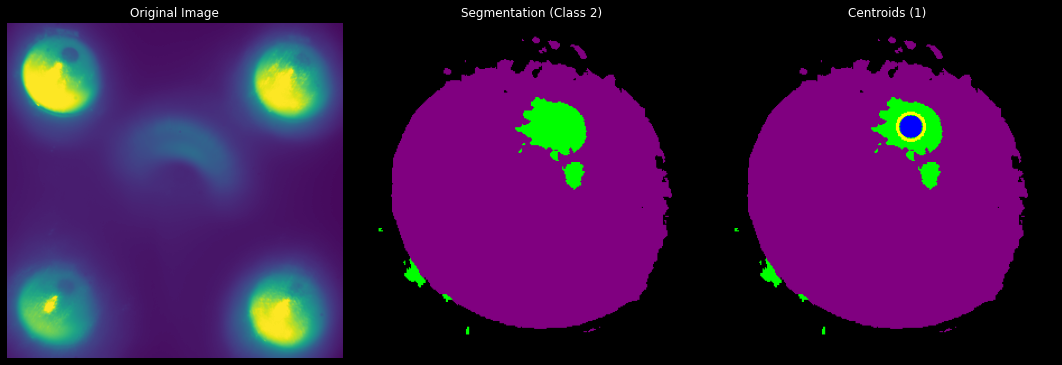

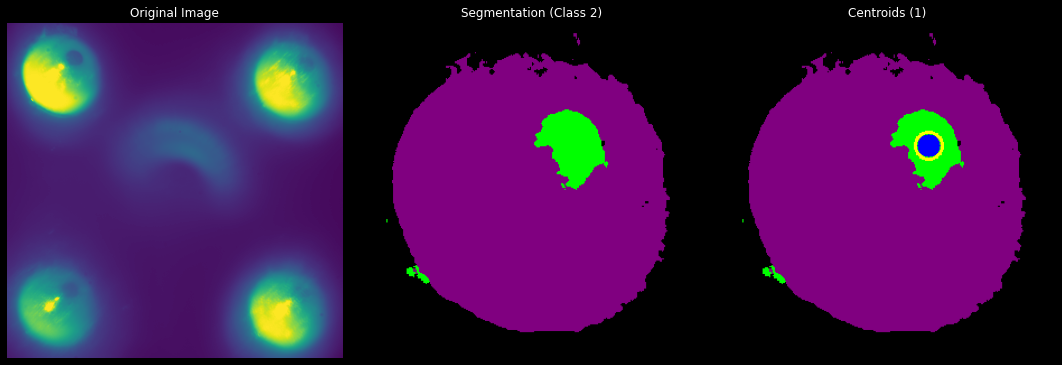

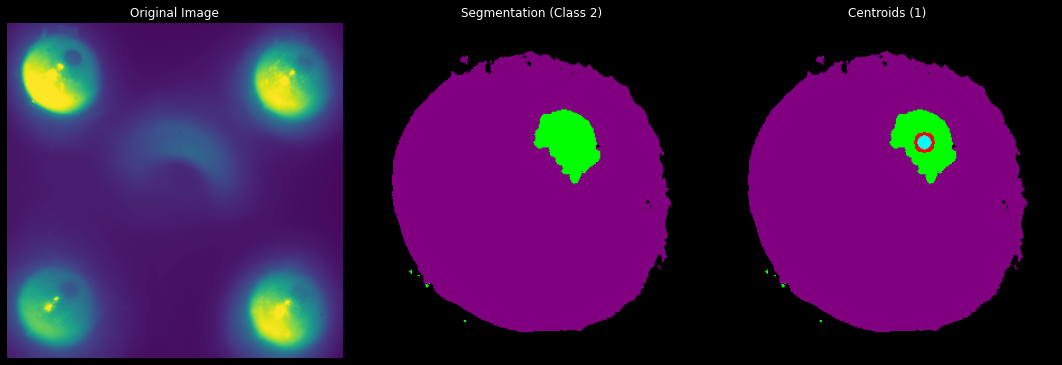

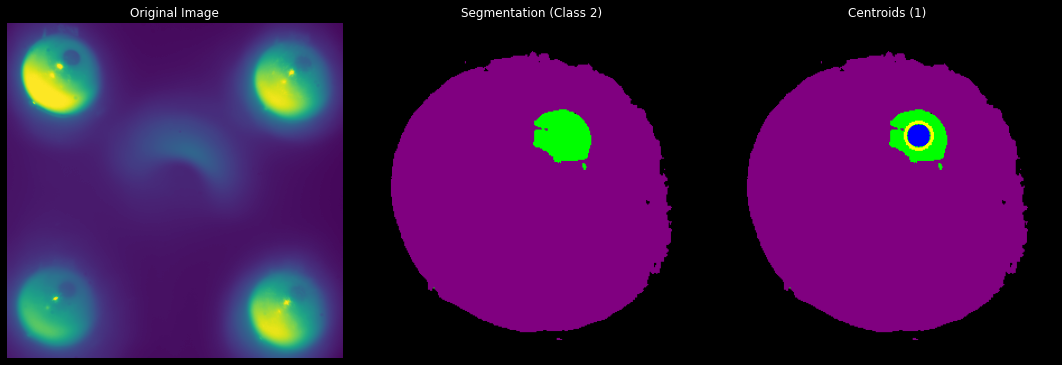

KeyboardInterrupt: 

In [ ]:
def run_centroid_detection(image_path, model=None):
    """
    Example usage of centroid detection pipeline.
    
    Args:
        image_path: Path to input image
        model: Optional trained segmentation model
    
    Returns:
        centroids: List of detected centroid coordinates
    """
    print(f"Processing image: {image_path}")
    
    # Step 1: Extract four regions
    input_array = extract_four_regions(image_path)
    
    if input_array is None:
        print("Failed to extract regions")
        return None
    
    print(f"Extracted regions shape: {input_array.shape}")
    
    # Step 2: Run segmentation (if model provided)
    if model is not None:
        input_tensor = torch.from_numpy(input_array).float().unsqueeze(0)
        
        with torch.no_grad():
            output = model(input_tensor)
            predictions = get_segmentation_results(output)
            segmentation_map = predictions.squeeze().cpu().numpy()
        
        # Step 3: Find centroids
        centroids, regions_info = find_class_centroids(
            segmentation_map,
            target_class=2,
            min_area=10,
            only_largest=True
        )
        
        print(f"Found {len(centroids)} centroid(s)")
        for i, (cx, cy) in enumerate(centroids):
            print(f"  Centroid {i+1}: ({cx:.2f}, {cy:.2f})")
        
        # Step 4: Visualize
        visualize_with_centroids(image_path, segmentation_map, centroids, regions_info)
        
        return centroids
    else:
        print("No model provided. Skipping segmentation.")
        return None


def create_and_validate_gaze_model(eye_points, screen_points, degree=2):
    """
    Create and validate a gaze polynomial model.
    
    Args:
        eye_points: Input eye tracking points (n_samples, 2)
        screen_points: Target screen coordinates (n_samples, 2)
        degree: Polynomial degree
    
    Returns:
        Trained GazePolynomialModel
    """
    print("Creating Gaze Polynomial Model...")
    
    # Create model
    model = GazePolynomialModel(degree=degree)
    
    # Train and evaluate
    results = validate_polynomial_model(
        model, eye_points, screen_points,
        test_size=0.2, cv=5
    )
    
    # Save model coefficients
    model.save_coefficients('gaze_model_coefficients.pkl')
    
    return model, results

# Example usage (uncomment to run):
# 
# 1. Batch Centroid Detection from a folder:
model = NewUnet()
# Configuration - Update these paths according to your environment
model.load_state_dict(torch.load(r'./best_model.pth'))
data_folder = './dataset/train/renamed_images'  # Folder containing PNG images
test_image_paths, test_label_paths = load_data_from_folder(data_folder)
df_centroids = save_all_segmentations(
    model=model,
    test_image_paths=test_image_paths,
    regions=None,
    output_dir='./segmentation_results_data'
)
#
# 2. Polynomial Regression using CSV files:
processor = GazeDataProcessor()
# Configuration - Update these paths according to your environment
angle_csv = "./coordinate_mapping.csv"
coord_csv = "./segmentation_results_data/class2_centroids.csv"
processor.load_angle_data(angle_csv)
processor.load_coordinate_data(coord_csv)
processor.match_data()
eye_train, eye_test, screen_train, screen_test = processor.split_data(test_size=0.2)
gaze_model = GazePolynomialModel(degree=2, alpha=0.1)
gaze_model.fit(eye_train, screen_train)
results = gaze_model.evaluate(eye_test, screen_test)
#
# 3. Save matched data
processor.save_matched_data('./output/matched_gaze_data.csv')

print("Centroid detection and polynomial regression pipeline ready!")

## Summary

This notebook provides a complete centroid detection and polynomial regression pipeline:

### Models:

- **NewUnet**: Lightweight U-Net segmentation model using depthwise separable convolutions
  - This is the model used to train best_model.pth
- **GazePolynomialModel**: Polynomial regression model for gaze point mapping

### Core Functions:

1. **extract_four_regions**: Extracts four corner regions from images
2. **get_segmentation_results**: Converts model output to segmentation maps
3. **find_class_centroids**: Finds centroids of specific classes in segmentation maps
4. **colorize_segmentation**: Converts segmentation maps to color images
5. **visualize_with_centroids**: Visualizes images with centroid markers
6. **save_all_segmentations**: Batch processes images and saves results
7. **validate_centroid_extraction**: Validates centroid extraction effectiveness
8. **validate_polynomial_model**: Validates polynomial regression effectiveness
9. **comprehensive_validation**: Validates entire pipeline

### Usage Workflow:

1. Initialize MetaUnet2 model (or load pre-trained weights)
2. Load your eye tracking and screen coordinate data
3. Call `comprehensive_validation()` to validate the entire pipeline
4. Or use individual validation functions for specific components

### Output:

- `class2_centroids.csv`: CSV file with centroid coordinates
- `npy_files/`: Directory containing segmentation results
- `visualizations/`: Directory containing visualization images
- `gaze_model_coefficients.pkl`: Saved model coefficients
- Performance metrics: MSE, RMSE, MAE, Correlation coefficients